# End-to-End Supervised Learning Workflow: HDB Resale Price Prediction with CatBoost

**Goal**: Build a supervised regression workflow to predict `resale_price` from the training dataset using `CatBoostRegressor`.

**Scenario**

The dataset contains flat, location, distance, school, and transport-related features. The target variable is `resale_price`, so this is a regression problem.

**Workflow**

1. Load and inspect the data.
2. Split features (`X`) and target (`Y`).
3. Identify categorical, binary, continuous numeric, and remaining numeric columns.
4. Build a preprocessing pipeline that engineers transaction-date features, imputes missing values with `0`, then uses `StandardScaler`, `MinMaxScaler`, and one-hot encoding.
5. Evaluate a baseline CatBoost model with 10-fold cross-validation.
6. Run a train-test split and evaluate CatBoost on held-out data.
7. Tune CatBoost hyperparameters with random search.
8. Inspect residuals and feature importances.


## 1. Imports and Data Loading

First, import the libraries used throughout the workflow and load the training dataset. The `id` column is used as the dataframe index.


In [90]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', 120)
sns.set_theme(style='whitegrid')


In [91]:
# load submission format
df_sub = pd.read_csv('data/sample_sub_reg.csv')
#df_sub.set_index('Id', inplace=True)

df_sub.shape
df_sub.head()


,Id,Predicted
0,114982,500000
1,95653,500000
2,40303,500000
3,109506,500000
4,100149,500000


In [92]:
# load test dataset
df_test = pd.read_csv('data/test.csv')
#df_test.set_index('id', inplace=True)

df_test.shape


/var/folders/44/bfmr660d6dz4w35pkrfps0700000gn/T/ipykernel_79813/125695310.py:2: DtypeWarning: Columns (0: postal) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test = pd.read_csv('data/test.csv')


(16737, 76)

In [93]:
# Load the training dataset.
df = pd.read_csv('data/train.csv')
#df.set_index('id', inplace=True)

df.shape


/var/folders/44/bfmr660d6dz4w35pkrfps0700000gn/T/ipykernel_79813/1523308996.py:2: DtypeWarning: Columns (0: postal) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/train.csv')


(150634, 77)

In [94]:
# Inspect data types, non-null counts, and example rows.
df.info()
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 150634 entries, 0 to 150633
Data columns (total 77 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         150634 non-null  int64  
 1   Tranc_YearMonth            150634 non-null  str    
 2   town                       150634 non-null  str    
 3   flat_type                  150634 non-null  str    
 4   block                      150634 non-null  str    
 5   street_name                150634 non-null  str    
 6   storey_range               150634 non-null  str    
 7   floor_area_sqm             150634 non-null  float64
 8   flat_model                 150634 non-null  str    
 9   lease_commence_date        150634 non-null  int64  
 10  resale_price               150634 non-null  float64
 11  Tranc_Year                 150634 non-null  int64  
 12  Tranc_Month                150634 non-null  int64  
 13  mid_storey                 150634 non-nu

,id,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,Tranc_Year,Tranc_Month,mid_storey,lower,upper,mid,full_flat_type,address,floor_area_sqft,hdb_age,max_floor_lvl,year_completed,residential,commercial,market_hawker,multistorey_carpark,precinct_pavilion,total_dwelling_units,1room_sold,2room_sold,3room_sold,4room_sold,5room_sold,exec_sold,multigen_sold,studio_apartment_sold,1room_rental,2room_rental,3room_rental,other_room_rental,postal,Latitude,Longitude,planning_area,Mall_Nearest_Distance,Mall_Within_500m,Mall_Within_1km,Mall_Within_2km,Hawker_Nearest_Distance,Hawker_Within_500m,Hawker_Within_1km,Hawker_Within_2km,hawker_food_stalls,hawker_market_stalls,mrt_nearest_distance,mrt_name,bus_interchange,mrt_interchange,mrt_latitude,mrt_longitude,bus_stop_nearest_distance,bus_stop_name,bus_stop_latitude,bus_stop_longitude,pri_sch_nearest_distance,pri_sch_name,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,88471,2016-05,KALLANG/WHAMPOA,4 ROOM,3B,UPP BOON KENG RD,10 TO 12,90.0,Model A,2006,680000.0,2016,5,11,10,12,11,4 ROOM Model A,"3B, UPP BOON KENG RD",968.760,15,25,2005,Y,N,N,N,N,142,0,0,0,96,46,0,0,0,0,0,0,0,382003,1.314299,103.872828,Kallang,1094.090418,NaN,NaN,7.0,154.753357,1.0,3.0,13.0,84,60,330.083069,Kallang,0,0,1.311540,103.871731,29.427395,Blk 3B,1.314433,103.872600,1138.633422,Geylang Methodist School,78,1,1.317659,103.882504,1138.633422,Geylang Methodist School,224,0,1.317659,103.882504
1,122598,2012-07,BISHAN,5 ROOM,153,BISHAN ST 13,07 TO 09,130.0,Improved,1987,665000.0,2012,7,8,7,9,8,5 ROOM Improved,"153, BISHAN ST 13",1399.320,34,9,1987,Y,N,N,N,N,112,0,0,0,56,56,0,0,0,0,0,0,0,570153,1.346086,103.855078,Bishan,866.941448,NaN,1.0,3.0,640.151925,NaN,1.0,7.0,80,77,903.659703,Bishan,1,1,1.350580,103.848305,58.207761,BLK 151A MKT,1.345659,103.855381,415.607357,Kuo Chuan Presbyterian Primary School,45,1,1.349783,103.854529,447.894399,Kuo Chuan Presbyterian Secondary School,232,0,1.350110,103.854892
2,170897,2013-07,BUKIT BATOK,EXECUTIVE,289B,BT BATOK ST 25,13 TO 15,144.0,Apartment,1997,838000.0,2013,7,14,13,15,14,EXECUTIVE Apartment,"289B, BT BATOK ST 25",1550.016,24,16,1996,Y,N,N,N,N,90,0,0,0,0,30,60,0,0,0,0,0,0,651289,1.343867,103.760535,Bukit Batok,1459.579948,NaN,NaN,4.0,1762.082341,NaN,NaN,1.0,84,95,1334.251197,Bukit Batok,1,0,1.349561,103.749970,214.747860,Blk 289E,1.344064,103.758613,498.849039,Keming Primary School,39,0,1.345245,103.756265,180.074558,Yusof Ishak Secondary School,188,0,1.342334,103.760013
3,86070,2012-04,BISHAN,4 ROOM,232,BISHAN ST 22,01 TO 05,103.0,Model A,1992,550000.0,2012,4,3,1,5,3,4 ROOM Model A,"232, BISHAN ST 22",1108.692,29,11,1990,Y,Y,N,N,N,75,0,0,0,68,7,0,0,0,0,0,0,0,570232,1.358245,103.845504,Bishan,950.175199,NaN,1.0,4.0,726.215262,NaN,1.0,9.0,32,86,907.453484,Bishan,1,1,1.350580,103.848305,43.396521,Opp Bishan Nth Shop Mall,1.358045,103.845169,389.515528,Catholic High School,20,1,1.354789,103.844934,389.515528,Catholic High School,253,1,1.354789,103.844934
4,153632,2017-12,YISHUN,4 ROOM,876,YISHUN ST 81,01 TO 03,83.0,Simplified,1987,298000.0,2017,12,2,1,3,2,4 ROOM Simplified,"876, YISHUN ST 81",893.412,34,4,1987,Y,N,N,N,N,48,0,0,0,30,18,0,0,0,0,0,0,0,760876,1.414745,103.835532,Yishun,729.771895,NaN,1.0,2.0,1540.151439,NaN,NaN,1.0,45,0,412.343032,Khatib,0,0,1.417131,103.832692,129.422752,Blk 873,1.415424,103.836477,401.200584,Naval Base Primary School,74,0,1.416280,103.838798,312.025435,Orchid Park Secondary School,208,0,1.414888,103.838335


In [95]:
# Check missing values before deciding how to handle them.
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]


Hawker_Within_500m       97390
Mall_Within_500m         92789
Hawker_Within_1km        60868
Hawker_Within_2km        29202
Mall_Within_1km          25426
Mall_Within_2km           1940
Mall_Nearest_Distance      829
dtype: int64

In [96]:
# for each column, do value counts:
for col in df.columns:
    print(f"Value counts for column '{col}':")
    print(df[col].value_counts(dropna=False))
    print("\n")

Value counts for column 'id':
id
88471     1
122598    1
170897    1
86070     1
153632    1
         ..
39814     1
147177    1
179087    1
21309     1
185947    1
Name: count, Length: 150634, dtype: int64


Value counts for column 'Tranc_YearMonth':
Tranc_YearMonth
2018-07    2088
2021-01    2019
2020-06    2008
2020-12    2007
2020-09    2005
           ... 
2013-12     818
2014-02     782
2013-02     714
2020-04     339
2020-05     284
Name: count, Length: 110, dtype: int64


Value counts for column 'town':
town
JURONG WEST        11451
WOODLANDS          11334
SENGKANG           11069
TAMPINES           10506
YISHUN             10042
BEDOK               9046
PUNGGOL             7793
HOUGANG             7555
ANG MO KIO          6908
CHOA CHU KANG       6343
BUKIT MERAH         5854
BUKIT PANJANG       5686
BUKIT BATOK         5623
TOA PAYOH           4817
PASIR RIS           4763
KALLANG/WHAMPOA     4340
QUEENSTOWN          4121
GEYLANG             3986
SEMBAWANG           3723
CLE

## 2. Initial Numeric Distribution Check

Plot the raw numeric columns before preprocessing. This helps verify which variables have wide ranges or skewed distributions.


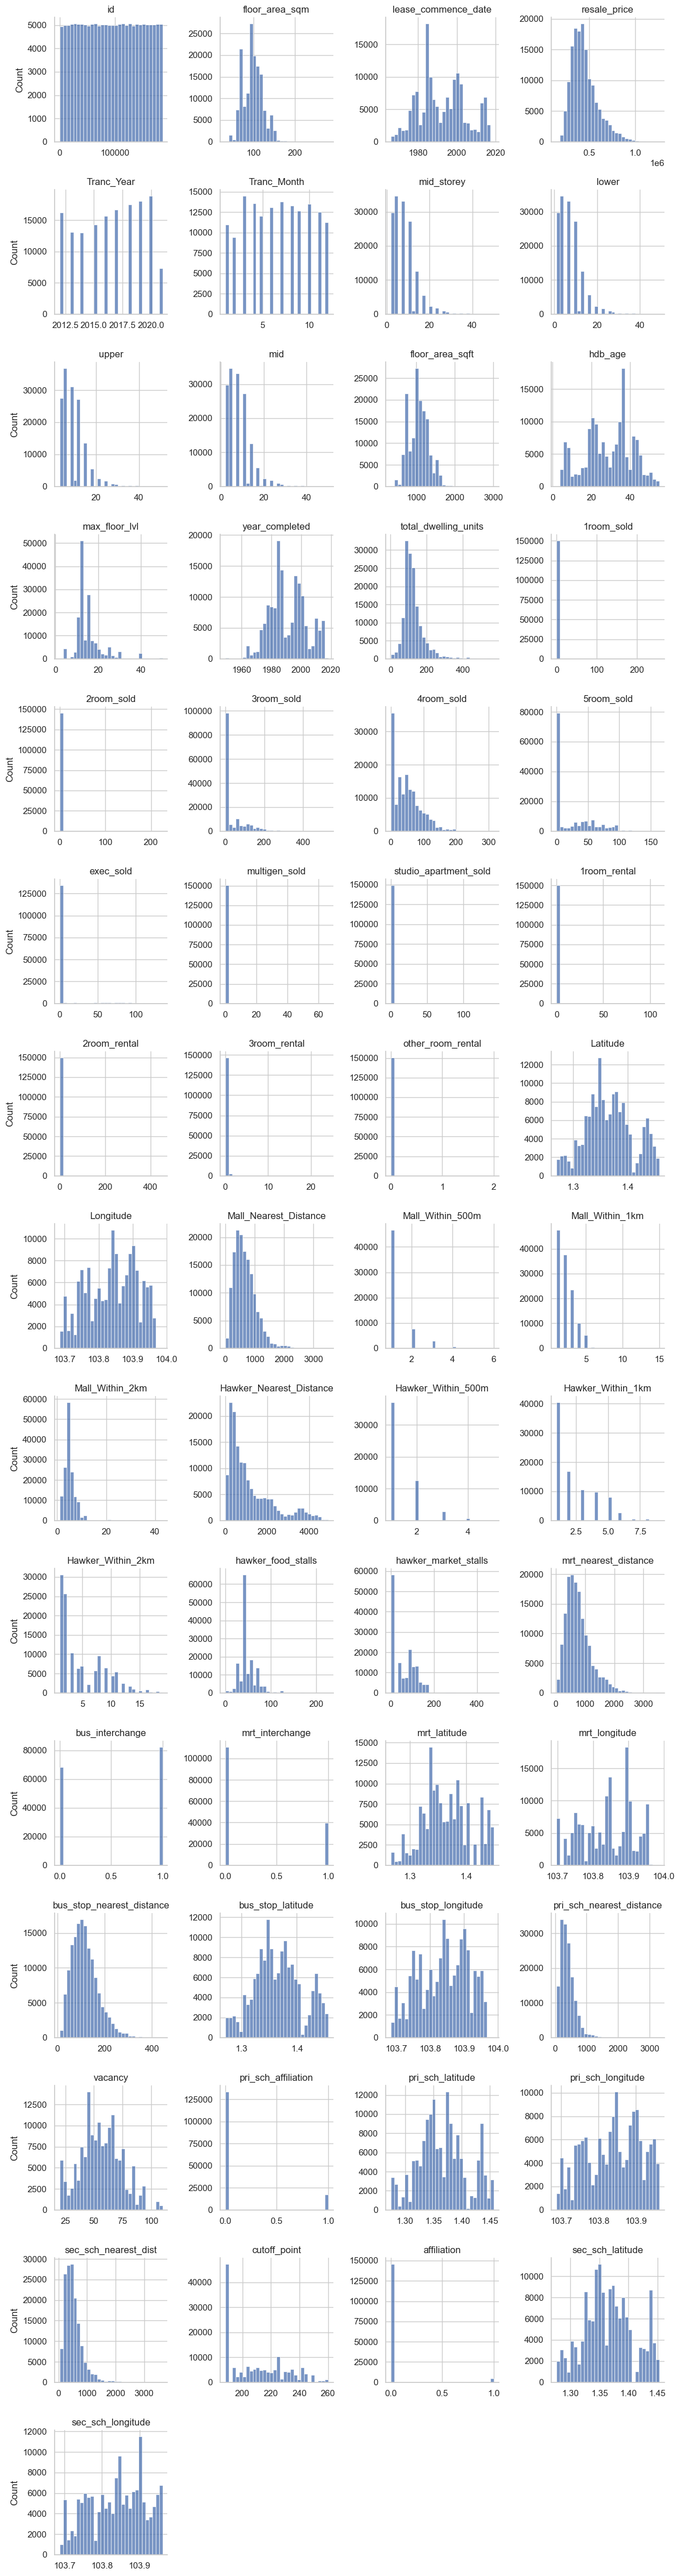

In [97]:
num_cols = df.select_dtypes('number').columns.tolist()
df_melted = df[num_cols].melt(var_name='variable', value_name='value')

g = sns.FacetGrid(df_melted, col='variable', col_wrap=4, height=3, sharey=False, sharex=False)
g.map(sns.histplot, 'value', bins=30, kde=False)
g.set_titles(col_template='{col_name}')
g.set_axis_labels('', 'Count')
plt.tight_layout()
plt.show()


## 3. Feature Engineering Inside the Pipeline

Define feature engineering as a sklearn transformer so the model can receive raw data at both training time and prediction time. The transformer learns the first transaction month during `fit`, then creates `days_from_first_transaction` during every `transform`.

In [98]:
class TransactionDateFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, transaction_col='Tranc_YearMonth'):
        self.transaction_col = transaction_col

    def fit(self, X, y=None):
        transaction_dates = pd.to_datetime(X[self.transaction_col], errors='coerce')
        self.first_transaction_date_ = transaction_dates.min()
        return self

    def transform(self, X):
        X = X.copy()
        transaction_dates = pd.to_datetime(X[self.transaction_col], errors='coerce')
        X['days_from_first_transaction'] = (
            transaction_dates - self.first_transaction_date_
        ).dt.days
        return X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return None
        return np.array(list(input_features) + ['days_from_first_transaction'], dtype=object)


class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None):
        self.columns = columns or []

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=self.columns, errors='ignore')

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return None
        return np.array([col for col in input_features if col not in self.columns], dtype=object)

## 4. Feature Selection and Target Split

Rows with missing values are removed instead of imputed. Then `resale_price` is separated as the target variable.


In [99]:
df_ml = df.copy()

Y = df_ml['resale_price']
X = df_ml.drop(columns=['resale_price'])

print(f'Original rows: {df.shape[0]}')
print(f'Rows kept for modeling: {df_ml.shape[0]}')
print(f'Features: {X.shape[1]}')
print(f'Target: {Y.name}')

X.head()

Original rows: 150634
Rows kept for modeling: 150634
Features: 76
Target: resale_price


,id,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,Tranc_Year,Tranc_Month,mid_storey,lower,upper,mid,full_flat_type,address,floor_area_sqft,hdb_age,max_floor_lvl,year_completed,residential,commercial,market_hawker,multistorey_carpark,precinct_pavilion,total_dwelling_units,1room_sold,2room_sold,3room_sold,4room_sold,5room_sold,exec_sold,multigen_sold,studio_apartment_sold,1room_rental,2room_rental,3room_rental,other_room_rental,postal,Latitude,Longitude,planning_area,Mall_Nearest_Distance,Mall_Within_500m,Mall_Within_1km,Mall_Within_2km,Hawker_Nearest_Distance,Hawker_Within_500m,Hawker_Within_1km,Hawker_Within_2km,hawker_food_stalls,hawker_market_stalls,mrt_nearest_distance,mrt_name,bus_interchange,mrt_interchange,mrt_latitude,mrt_longitude,bus_stop_nearest_distance,bus_stop_name,bus_stop_latitude,bus_stop_longitude,pri_sch_nearest_distance,pri_sch_name,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,88471,2016-05,KALLANG/WHAMPOA,4 ROOM,3B,UPP BOON KENG RD,10 TO 12,90.0,Model A,2006,2016,5,11,10,12,11,4 ROOM Model A,"3B, UPP BOON KENG RD",968.760,15,25,2005,Y,N,N,N,N,142,0,0,0,96,46,0,0,0,0,0,0,0,382003,1.314299,103.872828,Kallang,1094.090418,NaN,NaN,7.0,154.753357,1.0,3.0,13.0,84,60,330.083069,Kallang,0,0,1.311540,103.871731,29.427395,Blk 3B,1.314433,103.872600,1138.633422,Geylang Methodist School,78,1,1.317659,103.882504,1138.633422,Geylang Methodist School,224,0,1.317659,103.882504
1,122598,2012-07,BISHAN,5 ROOM,153,BISHAN ST 13,07 TO 09,130.0,Improved,1987,2012,7,8,7,9,8,5 ROOM Improved,"153, BISHAN ST 13",1399.320,34,9,1987,Y,N,N,N,N,112,0,0,0,56,56,0,0,0,0,0,0,0,570153,1.346086,103.855078,Bishan,866.941448,NaN,1.0,3.0,640.151925,NaN,1.0,7.0,80,77,903.659703,Bishan,1,1,1.350580,103.848305,58.207761,BLK 151A MKT,1.345659,103.855381,415.607357,Kuo Chuan Presbyterian Primary School,45,1,1.349783,103.854529,447.894399,Kuo Chuan Presbyterian Secondary School,232,0,1.350110,103.854892
2,170897,2013-07,BUKIT BATOK,EXECUTIVE,289B,BT BATOK ST 25,13 TO 15,144.0,Apartment,1997,2013,7,14,13,15,14,EXECUTIVE Apartment,"289B, BT BATOK ST 25",1550.016,24,16,1996,Y,N,N,N,N,90,0,0,0,0,30,60,0,0,0,0,0,0,651289,1.343867,103.760535,Bukit Batok,1459.579948,NaN,NaN,4.0,1762.082341,NaN,NaN,1.0,84,95,1334.251197,Bukit Batok,1,0,1.349561,103.749970,214.747860,Blk 289E,1.344064,103.758613,498.849039,Keming Primary School,39,0,1.345245,103.756265,180.074558,Yusof Ishak Secondary School,188,0,1.342334,103.760013
3,86070,2012-04,BISHAN,4 ROOM,232,BISHAN ST 22,01 TO 05,103.0,Model A,1992,2012,4,3,1,5,3,4 ROOM Model A,"232, BISHAN ST 22",1108.692,29,11,1990,Y,Y,N,N,N,75,0,0,0,68,7,0,0,0,0,0,0,0,570232,1.358245,103.845504,Bishan,950.175199,NaN,1.0,4.0,726.215262,NaN,1.0,9.0,32,86,907.453484,Bishan,1,1,1.350580,103.848305,43.396521,Opp Bishan Nth Shop Mall,1.358045,103.845169,389.515528,Catholic High School,20,1,1.354789,103.844934,389.515528,Catholic High School,253,1,1.354789,103.844934
4,153632,2017-12,YISHUN,4 ROOM,876,YISHUN ST 81,01 TO 03,83.0,Simplified,1987,2017,12,2,1,3,2,4 ROOM Simplified,"876, YISHUN ST 81",893.412,34,4,1987,Y,N,N,N,N,48,0,0,0,30,18,0,0,0,0,0,0,0,760876,1.414745,103.835532,Yishun,729.771895,NaN,1.0,2.0,1540.151439,NaN,NaN,1.0,45,0,412.343032,Khatib,0,0,1.417131,103.832692,129.422752,Blk 873,1.415424,103.836477,401.200584,Naval Base Primary School,74,0,1.416280,103.838798,312.025435,Orchid Park Secondary School,208,0,1.414888,103.838335


## 5. Building the Preprocessing Groups

The preprocessing groups are built in discrete steps:

1. Collect categorical and binary columns.
2. From the remaining numeric columns, identify continuous columns.
3. The leftover numeric columns are treated as non-continuous numeric features.


In [100]:
# Step 1: collect categorical and binary columns.
drop_cols = ['id', 'postal', 'town', 'street_name', 'block', 'Tranc_YearMonth']
model_input_cols = [col for col in X.columns if col not in drop_cols]

categorical_cols = X[model_input_cols].select_dtypes(include=['object', 'string', 'category']).columns.tolist()

numeric_candidate_cols = X[model_input_cols].select_dtypes(include='number').columns.tolist()
binary_cols = [
    col for col in numeric_candidate_cols
    if X[col].nunique(dropna=True) == 2
]

print(f'Dropped columns ({len(drop_cols)}):')
print(drop_cols)
print()
print(f'Categorical columns ({len(categorical_cols)}):')
print(categorical_cols)
print()
print(f'Binary columns ({len(binary_cols)}):')
print(binary_cols)

Dropped columns (6):
['id', 'postal', 'town', 'street_name', 'block', 'Tranc_YearMonth']

Categorical columns (15):
['flat_type', 'storey_range', 'flat_model', 'full_flat_type', 'address', 'residential', 'commercial', 'market_hawker', 'multistorey_carpark', 'precinct_pavilion', 'planning_area', 'mrt_name', 'bus_stop_name', 'pri_sch_name', 'sec_sch_name']

Binary columns (5):
['1room_sold', 'bus_interchange', 'mrt_interchange', 'pri_sch_affiliation', 'affiliation']


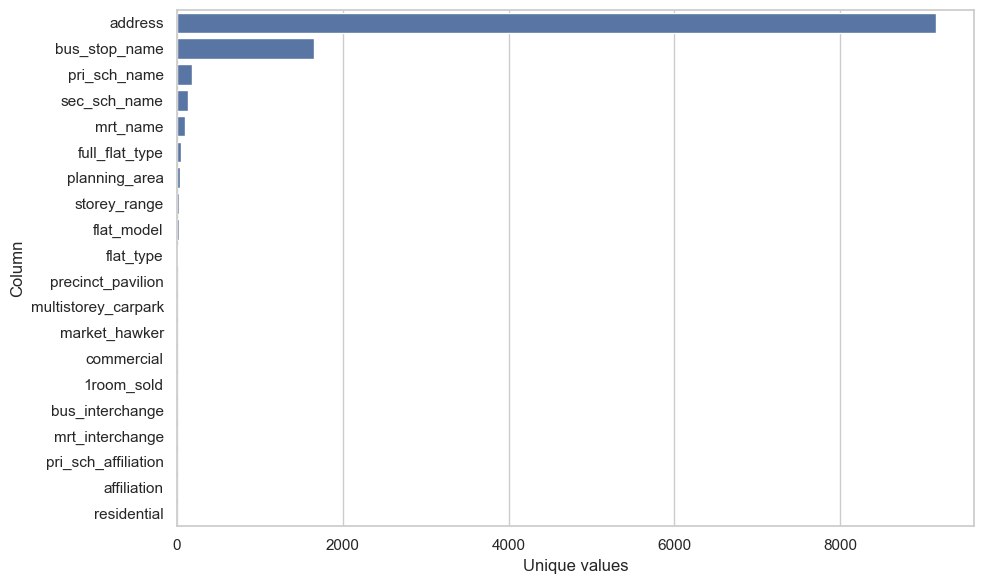

address                9157
bus_stop_name          1657
pri_sch_name            177
sec_sch_name            134
mrt_name                 94
full_flat_type           43
planning_area            32
storey_range             25
flat_model               20
flat_type                 7
precinct_pavilion         2
multistorey_carpark       2
market_hawker             2
commercial                2
1room_sold                2
bus_interchange           2
mrt_interchange           2
pri_sch_affiliation       2
affiliation               2
residential               1
Name: unique_values, dtype: int64

In [101]:
# Verify categorical and binary columns by cardinality.
cat_binary_summary = pd.concat([
    X[categorical_cols].nunique().rename('unique_values'),
    X[binary_cols].nunique().rename('unique_values'),
]).sort_values(ascending=False)

plt.figure(figsize=(10, max(4, 0.3 * len(cat_binary_summary))))
sns.barplot(x=cat_binary_summary.values, y=cat_binary_summary.index)
plt.xlabel('Unique values')
plt.ylabel('Column')
plt.tight_layout()
plt.show()

cat_binary_summary


In [102]:
# Step 2: identify continuous numeric columns from the remaining numeric columns.
engineered_numeric_cols = ['days_from_first_transaction']
numeric_cols = [col for col in numeric_candidate_cols if col not in binary_cols] + engineered_numeric_cols

continuous_cols = [
    col for col in numeric_cols
    if 'distance' in col.lower() or 'dist' in col.lower() or col in [
        'floor_area_sqm',
        'floor_area_sqft',
        'days_from_first_transaction',
        'Latitude',
        'Longitude',
        'mrt_latitude',
        'mrt_longitude',
        'bus_stop_latitude',
        'bus_stop_longitude',
        'pri_sch_latitude',
        'pri_sch_longitude',
        'sec_sch_latitude',
        'sec_sch_longitude',
    ]
]

print(f'Continuous numeric columns ({len(continuous_cols)}):')
print(continuous_cols)

Continuous numeric columns (19):
['floor_area_sqm', 'floor_area_sqft', 'Latitude', 'Longitude', 'Mall_Nearest_Distance', 'Hawker_Nearest_Distance', 'mrt_nearest_distance', 'mrt_latitude', 'mrt_longitude', 'bus_stop_nearest_distance', 'bus_stop_latitude', 'bus_stop_longitude', 'pri_sch_nearest_distance', 'pri_sch_latitude', 'pri_sch_longitude', 'sec_sch_nearest_dist', 'sec_sch_latitude', 'sec_sch_longitude', 'days_from_first_transaction']


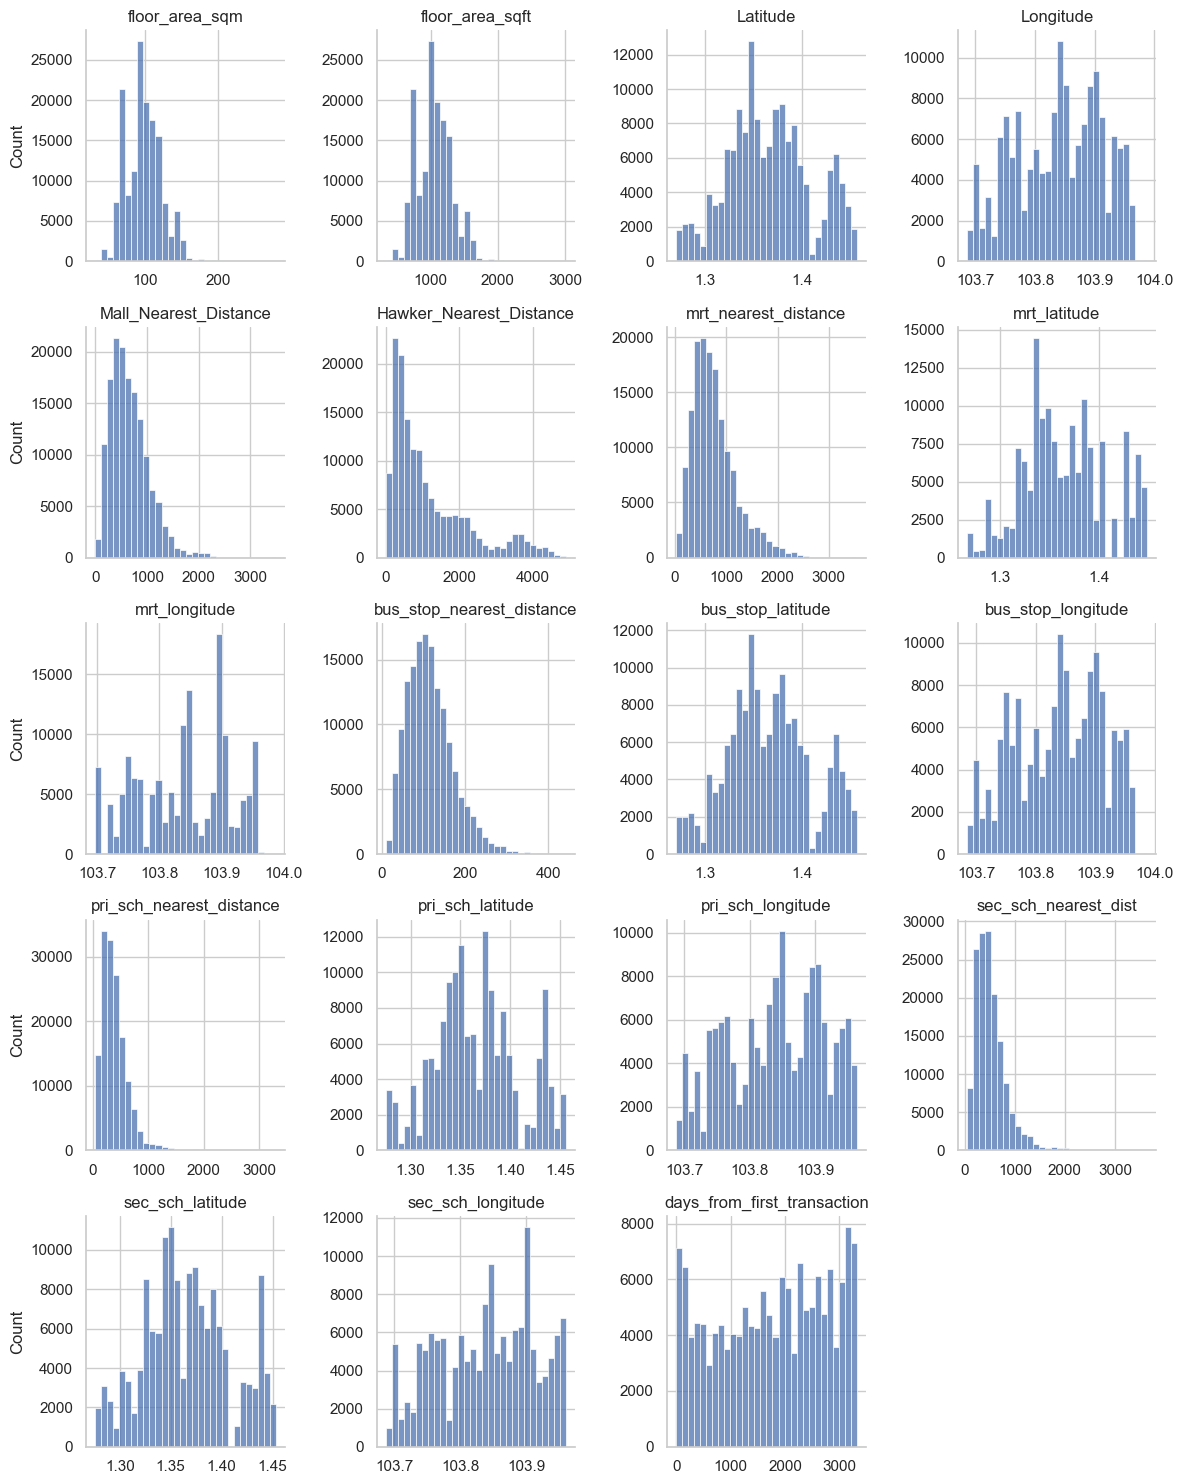

,count,mean,std,min,25%,50%,75%,max
floor_area_sqm,150634.0,97.197630,24.403040,31.000000,75.000000,95.000000,112.000000,280.000000
floor_area_sqft,150634.0,1046.235290,262.674321,333.684000,807.300000,1022.580000,1205.568000,3013.920000
Latitude,150634.0,1.366224,0.042850,1.270380,1.336285,1.363466,1.393323,1.457071
Longitude,150634.0,103.839391,0.072506,103.685228,103.774859,103.844907,103.898808,103.987804
Mall_Nearest_Distance,149805.0,664.239826,368.739209,0.000000,391.473823,602.818388,868.818288,3496.402910
Hawker_Nearest_Distance,150634.0,1173.700148,1076.701337,1.873295,372.132398,778.966980,1678.949229,4907.036414
mrt_nearest_distance,150634.0,765.007872,429.366039,21.971410,458.266301,682.621343,975.734180,3544.504228
mrt_latitude,150634.0,1.365667,0.042563,1.265982,1.336358,1.359703,1.392440,1.449057
mrt_longitude,150634.0,103.839400,0.072582,103.697143,103.773982,103.846412,103.895735,103.987305
bus_stop_nearest_distance,150634.0,115.258966,55.572855,9.001285,75.032491,107.765999,146.652409,443.964584


In [103]:
X_feature_preview = TransactionDateFeatures().fit_transform(X)

continuous_melted = X_feature_preview[continuous_cols].melt(
    var_name='variable',
    value_name='value',
)

g = sns.FacetGrid(continuous_melted, col='variable', col_wrap=4, height=3, sharey=False, sharex=False)
g.map(sns.histplot, 'value', bins=30, kde=False)
g.set_titles(col_template='{col_name}')
g.set_axis_labels('', 'Count')
plt.tight_layout()
plt.show()

X_feature_preview[continuous_cols].describe().T

In [104]:
# Step 3: remaining non-continuous numeric columns.
other_numeric_cols = [
    col for col in numeric_cols
    if col not in continuous_cols and col not in engineered_numeric_cols
]

print(f'Remaining numeric columns ({len(other_numeric_cols)}):')
print(other_numeric_cols)

Remaining numeric columns (32):
['lease_commence_date', 'Tranc_Year', 'Tranc_Month', 'mid_storey', 'lower', 'upper', 'mid', 'hdb_age', 'max_floor_lvl', 'year_completed', 'total_dwelling_units', '2room_sold', '3room_sold', '4room_sold', '5room_sold', 'exec_sold', 'multigen_sold', 'studio_apartment_sold', '1room_rental', '2room_rental', '3room_rental', 'other_room_rental', 'Mall_Within_500m', 'Mall_Within_1km', 'Mall_Within_2km', 'Hawker_Within_500m', 'Hawker_Within_1km', 'Hawker_Within_2km', 'hawker_food_stalls', 'hawker_market_stalls', 'vacancy', 'cutoff_point']


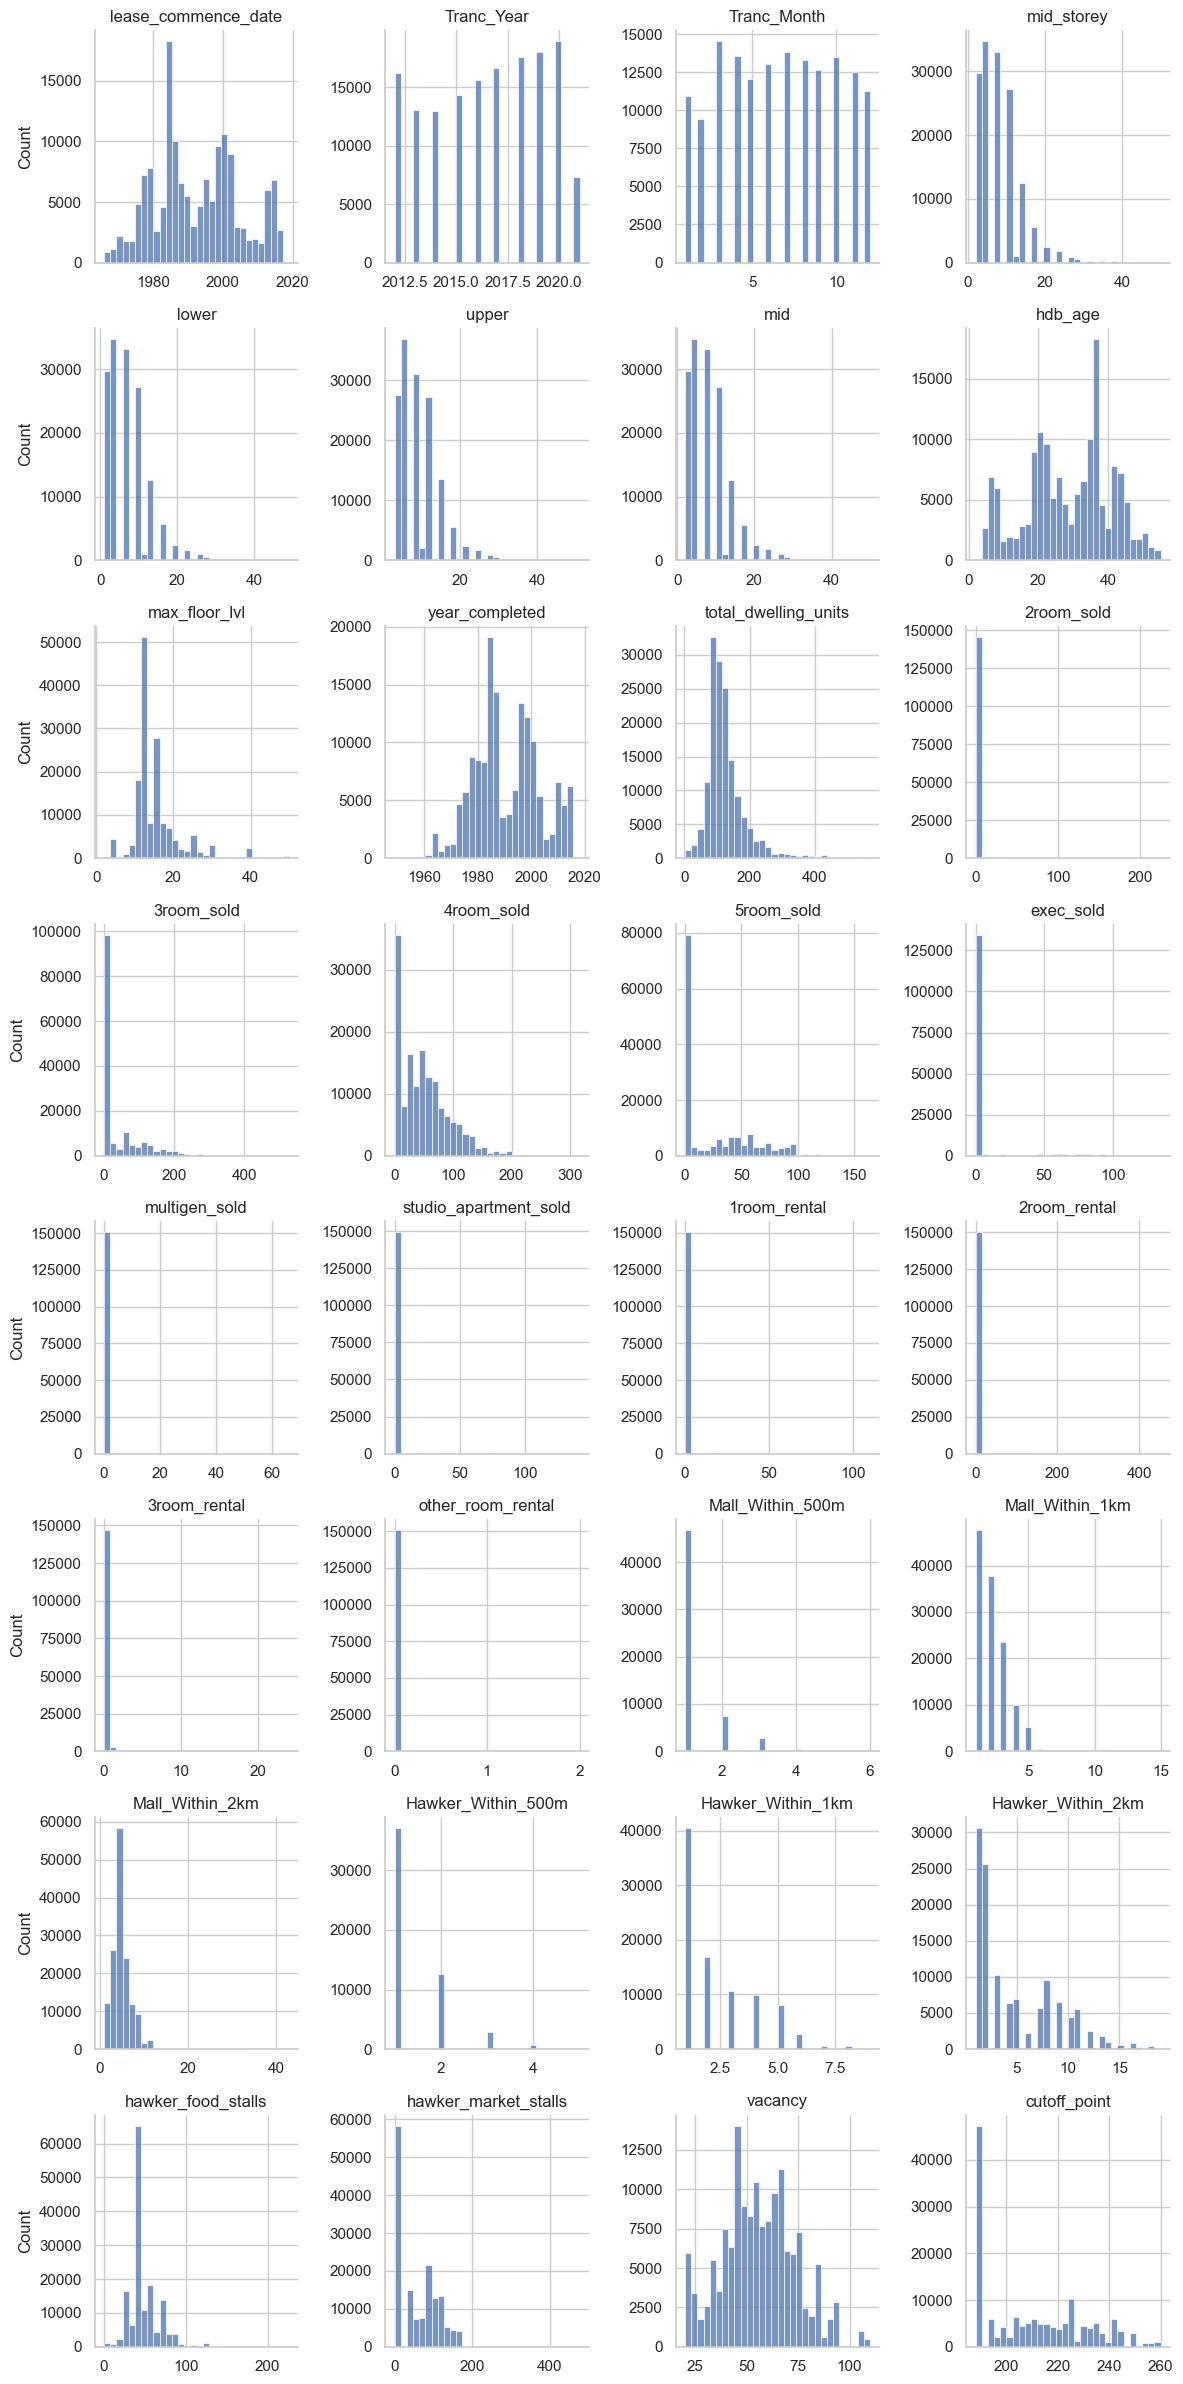

,count,mean,std,min,25%,50%,75%,max
lease_commence_date,150634.0,1992.448464,12.138829,1966.0,1984.0,1992.0,2001.0,2019.0
Tranc_Year,150634.0,2016.489551,2.752396,2012.0,2014.0,2017.0,2019.0,2021.0
Tranc_Month,150634.0,6.580500,3.345468,1.0,4.0,7.0,9.0,12.0
mid_storey,150634.0,8.284823,5.508074,2.0,5.0,8.0,11.0,50.0
lower,150634.0,7.248370,5.515155,1.0,4.0,7.0,10.0,49.0
upper,150634.0,9.321275,5.507364,3.0,6.0,9.0,12.0,51.0
mid,150634.0,8.284823,5.508074,2.0,5.0,8.0,11.0,50.0
hdb_age,150634.0,28.551536,12.138829,2.0,20.0,29.0,37.0,55.0
max_floor_lvl,150634.0,15.139816,6.232492,2.0,12.0,13.0,16.0,50.0
year_completed,150634.0,1990.922906,12.202185,1949.0,1983.0,1989.0,1999.0,2018.0


In [105]:
# Verify remaining non-continuous numeric columns.
other_numeric_melted = X[other_numeric_cols].melt(var_name='variable', value_name='value')

g = sns.FacetGrid(other_numeric_melted, col='variable', col_wrap=4, height=3, sharey=False, sharex=False)
g.map(sns.histplot, 'value', bins=30, kde=False)
g.set_titles(col_template='{col_name}')
g.set_axis_labels('', 'Count')
plt.tight_layout()
plt.show()

X[other_numeric_cols].describe().T


## 6. Building the Preprocessing Pipeline

This is the main sklearn pipeline pattern used by the rest of the notebook. Raw feature data goes into `Pipeline`; the `feature_engineering` step creates `days_from_first_transaction`, the `preprocessor` step fills missing values with `0`, scales/encodes columns, and the final `model` step fits or predicts.

In [106]:
std_scale_cols = continuous_cols
minmax_scale_cols = binary_cols + other_numeric_cols

std_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler()),
])

minmax_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', MinMaxScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='0')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(transformers=[
    ('std', std_pipeline, std_scale_cols),
    ('minmax', minmax_pipeline, minmax_scale_cols),
    ('cat', categorical_pipeline, categorical_cols),
])


def make_regression_pipeline(model):
    return Pipeline(steps=[
        ('feature_engineering', TransactionDateFeatures()),
        ('drop_columns', DropColumns(drop_cols)),
        ('preprocessor', preprocessor),
        ('model', model),
    ])


preprocessing_summary = pd.DataFrame({
    'group': ['feature_engineering', 'dropped', 'imputation', 'categorical', 'binary', 'standard_scaled_continuous', 'minmax_scaled_numeric'],
    'column_count': [1, len(drop_cols), X.drop(columns=drop_cols, errors='ignore').isna().sum().gt(0).sum(), len(categorical_cols), len(binary_cols), len(std_scale_cols), len(minmax_scale_cols)],
})

preprocessing_summary

,group,column_count
0,feature_engineering,1
1,dropped,6
2,imputation,7
3,categorical,15
4,binary,5
5,standard_scaled_continuous,19
6,minmax_scaled_numeric,37


## 7. Final Transformed Data Check

This cell fits the preprocessor to the cleaned feature matrix so the transformed columns can be inspected before modeling. The facet grid shows only the scaled numeric columns because one-hot encoding expands the categorical features into many sparse indicator columns.


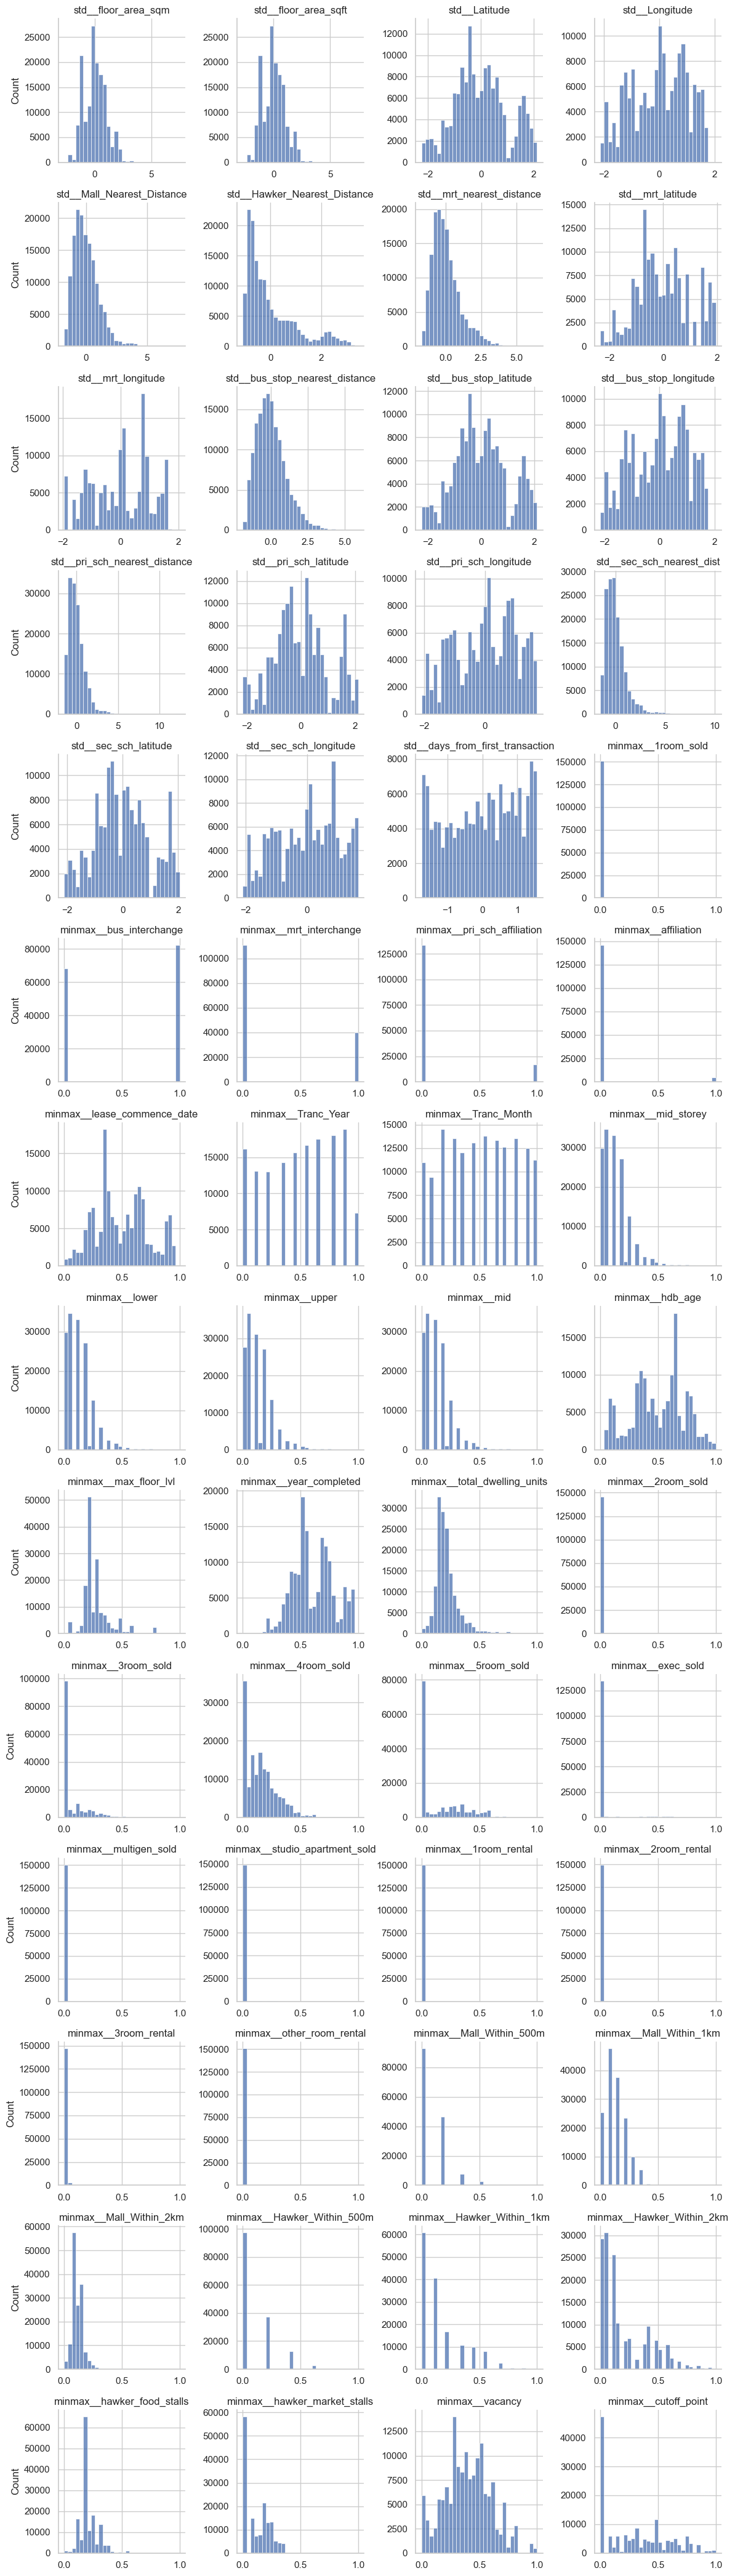

((150634, 11411),
                                      count          mean       std       min  \
 std__floor_area_sqm               150634.0 -3.018889e-17  1.000003 -2.712689   
 std__floor_area_sqft              150634.0 -1.939636e-16  1.000003 -2.712689   
 std__Latitude                     150634.0  1.010951e-15  1.000003 -2.236721   
 std__Longitude                    150634.0 -1.482407e-14  1.000003 -2.126204   
 std__Mall_Nearest_Distance        150634.0  6.037778e-18  1.000003 -1.780594   
 std__Hawker_Nearest_Distance      150634.0 -1.920768e-16  1.000003 -1.088353   
 std__mrt_nearest_distance         150634.0 -1.239631e-16  1.000003 -1.730549   
 std__mrt_latitude                 150634.0  2.590773e-15  1.000003 -2.342072   
 std__mrt_longitude                150634.0  1.767710e-13  1.000003 -1.959949   
 std__bus_stop_nearest_distance    150634.0  1.881145e-16  1.000003 -1.912049   
 std__bus_stop_latitude            150634.0  3.900027e-15  1.000003 -2.227310   
 std__bus_

In [107]:
preprocessing_pipeline = Pipeline(steps=[
    ('feature_engineering', TransactionDateFeatures()),
    ('drop_columns', DropColumns(drop_cols)),
    ('preprocessor', preprocessor),
])

X_transformed = preprocessing_pipeline.fit_transform(X)
transformed_feature_names = preprocessing_pipeline.named_steps['preprocessor'].get_feature_names_out()

X_transformed_df = pd.DataFrame(
    X_transformed.toarray() if hasattr(X_transformed, 'toarray') else X_transformed,
    columns=transformed_feature_names,
    index=X.index,
)

scaled_feature_names = [
    col for col in transformed_feature_names
    if col.startswith('std__') or col.startswith('minmax__')
]

transformed_melted = X_transformed_df[scaled_feature_names].melt(
    var_name='variable',
    value_name='value',
)

g = sns.FacetGrid(transformed_melted, col='variable', col_wrap=4, height=3, sharey=False, sharex=False)
g.map(sns.histplot, 'value', bins=30, kde=False)
g.set_titles(col_template='{col_name}')
g.set_axis_labels('', 'Count')
plt.tight_layout()
plt.show()

X_transformed_df.shape, X_transformed_df[scaled_feature_names].describe().T

## 8. Train-Test Split

Create the held-out test split first. Cross-validation and hyperparameter tuning below use only `X_train` and `Y_train`, so the test split remains untouched until final evaluation.

In [108]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.1, random_state=42
)

X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((135570, 76), (15064, 76), (135570,), (15064,))

## 9. Helper Function for Regression Metrics

This helper keeps the evaluation output consistent across CatBoost model runs.

In [109]:
def regression_metrics(model_name, y_train, y_train_pred, y_test, y_test_pred):
    return pd.DataFrame({
        'model': [model_name, model_name],
        'split': ['train', 'test'],
        'MAE': [
            mean_absolute_error(y_train, y_train_pred),
            mean_absolute_error(y_test, y_test_pred),
        ],
        'RMSE': [
            mean_squared_error(y_train, y_train_pred) ** 0.5,
            mean_squared_error(y_test, y_test_pred) ** 0.5,
        ],
        'R2': [
            r2_score(y_train, y_train_pred),
            r2_score(y_test, y_test_pred),
        ],
    })

## 10. Baseline CatBoost with 10-Fold Cross-Validation

Run 10-fold cross-validation on the training split only. This estimates baseline model stability without using the held-out test split.

In [110]:
catboost_baseline_cv_pipeline = make_regression_pipeline(
    CatBoostRegressor(
        loss_function='RMSE',
        random_seed=42,
        verbose=0,
        allow_writing_files=False,
        thread_count=1,
    )
)

kfold = KFold(n_splits=10, shuffle=True, random_state=42)
cv_results = cross_validate(
    catboost_baseline_cv_pipeline,
    X_train,
    Y_train,
    cv=kfold,
    scoring={
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2',
    },
    n_jobs=-1,
)

catboost_cv_metrics = pd.DataFrame({
    'fold': range(1, kfold.get_n_splits() + 1),
    'MAE': -cv_results['test_mae'],
    'RMSE': -cv_results['test_rmse'],
    'R2': cv_results['test_r2'],
})

catboost_cv_summary = catboost_cv_metrics[['MAE', 'RMSE', 'R2']].agg(['mean', 'std'])
catboost_cv_summary

,MAE,RMSE,R2
mean,17854.333492,24362.815489,0.971110
std,122.843146,344.894191,0.000701


## 11. Baseline CatBoost Fit

Fit the baseline CatBoost model on the training split and evaluate once on the held-out test split.

In [111]:
catboost_baseline_pipeline = make_regression_pipeline(
    CatBoostRegressor(
        loss_function='RMSE',
        random_seed=42,
        verbose=0,
        allow_writing_files=False,
        thread_count=-1,
    )
)

catboost_baseline_pipeline.fit(X_train, Y_train)

Y_train_pred_catboost = catboost_baseline_pipeline.predict(X_train)
Y_test_pred_catboost = catboost_baseline_pipeline.predict(X_test)

catboost_baseline_split_metrics = regression_metrics(
    'CatBoost Baseline',
    Y_train,
    Y_train_pred_catboost,
    Y_test,
    Y_test_pred_catboost,
)

catboost_baseline_split_metrics

,model,split,MAE,RMSE,R2
0,CatBoost Baseline,train,17353.875353,23396.590168,0.973362
1,CatBoost Baseline,test,17616.897005,23928.638581,0.971960


## 12. CatBoost Hyperparameter Tuning with Built-In Grid Search

CatBoost's built-in `grid_search()` tunes the CatBoost model after the training split has been preprocessed. The selected parameters are then placed back into the full pipeline so raw data still flows through feature engineering, column dropping, imputation, scaling, and one-hot encoding before CatBoost.

In [112]:
catboost_tuning_preprocessor = Pipeline(steps=[
    ('feature_engineering', TransactionDateFeatures()),
    ('drop_columns', DropColumns(drop_cols)),
    ('preprocessor', preprocessor),
])

X_train_tuned = catboost_tuning_preprocessor.fit_transform(X_train)
X_test_tuned = catboost_tuning_preprocessor.transform(X_test)

catboost_param_grid = {
    'iterations': [600, 900],
    'learning_rate': [0.03, 0.06],
    'depth': [6, 8],
    'l2_leaf_reg': [3, 10],
}

catboost_grid_model = CatBoostRegressor(
    loss_function='RMSE',
    random_seed=42,
    verbose=0,
    allow_writing_files=False,
    thread_count=-1,
)

catboost_grid_search = catboost_grid_model.grid_search(
    catboost_param_grid,
    X=X_train_tuned,
    y=Y_train,
    cv=kfold,
    partition_random_seed=42,
    shuffle=True,
    refit=True,
    verbose=False,
)

best_catboost_params = catboost_grid_search['params']

best_catboost_pipeline = make_regression_pipeline(
    CatBoostRegressor(
        loss_function='RMSE',
        random_seed=42,
        verbose=0,
        allow_writing_files=False,
        thread_count=-1,
        **best_catboost_params,
    )
)

best_catboost_pipeline.fit(X_train, Y_train)

Y_train_pred_catboost_best = best_catboost_pipeline.predict(X_train)
Y_test_pred_catboost_best = best_catboost_pipeline.predict(X_test)

best_catboost_metrics = regression_metrics(
    'Tuned CatBoost',
    Y_train,
    Y_train_pred_catboost_best,
    Y_test,
    Y_test_pred_catboost_best,
)

best_catboost_params, best_catboost_metrics

/Users/zacang/Documents/School/NTU_SCTP_DS4/Mod3/sctp-dsai-kaggle-competition/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:87: UserWarning: The groups parameter is ignored by KFold
  warnings.warn(



bestTest = 29429.8176
bestIteration = 599


bestTest = 26565.47382
bestIteration = 599


bestTest = 29936.79333
bestIteration = 599


bestTest = 26955.29489
bestIteration = 599


bestTest = 27425.33253
bestIteration = 899


bestTest = 25395.06412
bestIteration = 899


bestTest = 27799.17579
bestIteration = 899


bestTest = 25834.25591
bestIteration = 898


bestTest = 26698.43971
bestIteration = 599


bestTest = 24660.43758
bestIteration = 599


bestTest = 27260.12833
bestIteration = 599


bestTest = 25093.3689
bestIteration = 599


bestTest = 25304.93938
bestIteration = 899


bestTest = 23841.46385
bestIteration = 899


bestTest = 25736.53183
bestIteration = 899


bestTest = 24313.05625
bestIteration = 899

Training on fold [0/10]

bestTest = 24034.18911
bestIteration = 899

Training on fold [1/10]

bestTest = 23775.99949
bestIteration = 899

Training on fold [2/10]

bestTest = 24153.54941
bestIteration = 899

Training on fold [3/10]

bestTest = 23683.15531
bestIteration = 899

Traini

({'depth': 8, 'learning_rate': 0.06, 'l2_leaf_reg': 3, 'iterations': 900},
             model  split           MAE          RMSE        R2
 0  Tuned CatBoost  train  16930.422644  22868.618419  0.974551
 1  Tuned CatBoost   test  17303.170538  23543.389389  0.972855)

## 13. Model Comparison

Compare the baseline and tuned CatBoost models on the held-out test split.

In [113]:
model_comparison = pd.concat(
    [catboost_baseline_split_metrics, best_catboost_metrics],
    ignore_index=True,
)

model_comparison.sort_values(['split', 'RMSE'])

,model,split,MAE,RMSE,R2
3,Tuned CatBoost,test,17303.170538,23543.389389,0.972855
1,CatBoost Baseline,test,17616.897005,23928.638581,0.971960
2,Tuned CatBoost,train,16930.422644,22868.618419,0.974551
0,CatBoost Baseline,train,17353.875353,23396.590168,0.973362


## 14. Fit Final Model, Predict Test Data, and Save Model

Fit a final CatBoost pipeline on all labeled training data using the best grid-search parameters. Then predict `df_test` and save the fitted pipeline for reuse.

In [114]:
from pathlib import Path
import cloudpickle

catboost_final_pipeline = make_regression_pipeline(
    CatBoostRegressor(
        loss_function='RMSE',
        random_seed=42,
        verbose=0,
        allow_writing_files=False,
        thread_count=-1,
        **best_catboost_params,
    )
)

catboost_final_pipeline.fit(X, Y)

## Run predict on test set:

df_test_predictions = catboost_final_pipeline.predict(df_test)
catboost_test_predictions = pd.DataFrame({
    'id': df_test['id'].to_numpy(),
    'resale_price': df_test_predictions,
})

model_dir = Path('models')
model_dir.mkdir(exist_ok=True)
catboost_model_path = model_dir / 'catboost_grid_search_final.pkl'
with open(catboost_model_path, 'wb') as file:
    cloudpickle.dump(catboost_final_pipeline, file)

catboost_model_path, catboost_test_predictions.head()

(PosixPath('models/catboost_grid_search_final.pkl'),
        id   resale_price
 0  114982  380297.025305
 1   95653  463576.038960
 2   40303  360288.335203
 3  109506  283276.686000
 4  100149  426114.174312)

## 15. Save Kaggle Submission CSV

In [115]:
df_submission = pd.merge(
    df_sub[['Id']],
    catboost_test_predictions,
    left_on='Id',
    right_on='id',
    how='left',
)
df_submission.drop(columns=['id'], inplace=True)
df_submission.rename(columns={'resale_price': 'Predicted'}, inplace=True)
df_submission.to_csv('submission_catboost.csv', index=False)

df_submission.head()

,Id,Predicted
0,114982,380297.025305
1,95653,463576.038960
2,40303,360288.335203
3,109506,283276.686000
4,100149,426114.174312


## 16. Residual Diagnostics

Inspect residuals from the tuned model on the held-out test split.

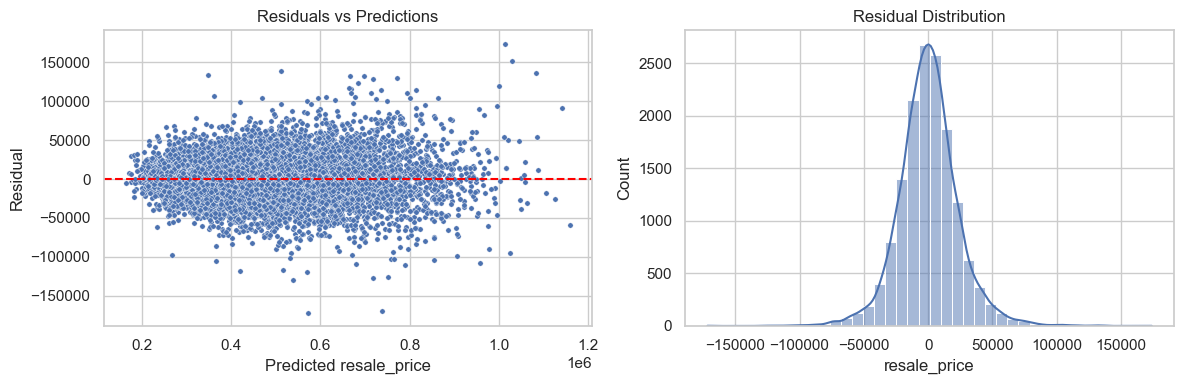

In [116]:
residuals = Y_test - Y_test_pred_catboost_best

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x=Y_test_pred_catboost_best, y=residuals, ax=axes[0], s=15)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted resale_price')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predictions')

sns.histplot(residuals, bins=40, kde=True, ax=axes[1])
axes[1].set_title('Residual Distribution')
plt.tight_layout()
plt.show()

## 17. Feature Importance

CatBoost exposes feature importances after fitting. These importances are based on the transformed feature matrix, so one-hot encoded categorical values appear as separate features.

In [117]:
catboost_feature_names = best_catboost_pipeline.named_steps['preprocessor'].get_feature_names_out()
catboost_importances = best_catboost_pipeline.named_steps['model'].get_feature_importance()

feature_importance_summary = pd.DataFrame({
    'feature': catboost_feature_names,
    'importance': catboost_importances,
})

feature_importance_summary.sort_values('importance', ascending=False).head(20)

ValueError: All arrays must be of the same length